In [33]:
# prepare your data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from openbox import space as sp
import pandas as pd
import xgboost

%matplotlib inline

In [34]:
df_yield = pd.read_csv('../data/flow2.tsv', sep='\t')
features = df_yield.drop(['yield'], axis=1)
y = df_yield['yield']
X = pd.DataFrame(features ,columns=features.columns)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [36]:
# train an XGBoost model
model = xgboost.XGBRegressor(
    learning_rate = 0.1,
        subsample = 0.5,
        colsample_bynode = 0.6,
        reg_lambda = 1e-3,).fit(X_train, y_train)

In [37]:
# predict the known best
model.predict(X.iloc[-3:])

array([87.622154, 78.85881 , 81.37922 ], dtype=float32)

In [38]:
from sklearn.metrics import r2_score
print(f'r2 score is: {r2_score(y_test, model.predict(X_test))}')

r2 score is: 0.8296513041732435


In [39]:
def get_configspace():
    space = sp.Space()
    m_B = sp.Real("m_B", 2, 3, default_value=2.61, q=0.1)
    t_RT1 = sp.Real("t_RT1", 2, 40, default_value=35.25, q=1)
    T_drawH = sp.Real("T_drawH", -55, -15, default_value=-34.3, q=1)
    m_C = sp.Real("m_C", 0.5, 4, default_value=2.34, q=0.1)
    t_RT2 = sp.Real("t_RT2", 3, 303, default_value=138.9, q=10)
    T_methyl = sp.Real("T_methyl", -50, -10, default_value=-34, q=1)
    space.add_variables([m_B, t_RT1, T_drawH, m_C, t_RT2,
                      T_methyl])
    return space

def objective_function(config: sp.Configuration):
    params = config.get_dictionary().copy()
    pred = 100 - model.predict(pd.DataFrame([params.values()], columns=X.columns))
    return dict(objectives=pred)

In [40]:
from openbox import Optimizer

# Run
opt = Optimizer(
    objective_function,
    get_configspace(),
    num_objectives=1,
    num_constraints=0,
    max_runs=1000,
    surrogate_type='lightgbm',
    task_id='flow2',
    visualization='advanced',
    advisor_type='tpe',
    initial_runs=3,
    init_strategy='random_explore_first',
)
history = opt.run()

[2023-03-17 11:04:28,727][flow2][INFO][color_logger.py:203] Logfile: /home/z/zsl/flow/flow2/logs/flow2_2023-03-17-11-04-28-726594.log
[2023-03-17 11:04:28,737][flow2][INFO][html_visualizer.py:462] Please open the html file to view visualization result: file:///home/z/zsl/flow/flow2/logs/history/flow2/flow2_2023-03-17-11-04-28-735583.html
  0%|          | 0/1000 [00:00<?, ?it/s][2023-03-17 11:04:28,751][flow2][INFO][generic_smbo.py:295] Iter 1, objectives: [49.31332778930664].
[2023-03-17 11:04:28,765][flow2][INFO][generic_smbo.py:295] Iter 2, objectives: [56.214874267578125].
[2023-03-17 11:04:28,779][flow2][INFO][generic_smbo.py:295] Iter 3, objectives: [49.27285385131836].
[2023-03-17 11:04:28,790][flow2][INFO][generic_smbo.py:295] Iter 4, objectives: [51.17228698730469].
[2023-03-17 11:04:28,802][flow2][INFO][generic_smbo.py:295] Iter 5, objectives: [56.03829574584961].
[2023-03-17 11:04:28,821][flow2][INFO][generic_smbo.py:295] Iter 6, objectives: [52.314205169677734].
[2023-03-17 

In [45]:
history = opt.get_history()
print(history)

[2023-03-17 11:09:17,168][flow2][INFO][history.py:765] Too many incumbents in history. Only show 5/334 of them.


+-------------------------+-----------------+-----------------+-----------------+-----------------+-----------------+
| Parameters              | Optimal Value 1 | Optimal Value 2 | Optimal Value 3 | Optimal Value 4 | Optimal Value 5 |
+-------------------------+-----------------+-----------------+-----------------+-----------------+-----------------+
| T_drawH                 | -45.000000      | -38.000000      | -53.000000      | -30.000000      | -33.000000      |
| T_methyl                | -33.000000      | -28.000000      | -22.000000      | -16.000000      | -15.000000      |
| m_B                     | 2.300000        | 2.300000        | 2.300000        | 2.000000        | 2.100000        |
| m_C                     | 2.800000        | 2.800000        | 2.800000        | 2.800000        | 2.800000        |
| t_RT1                   | 13.000000       | 12.000000       | 13.000000       | 13.000000       | 14.000000       |
| t_RT2                   | 33.000000       | 43.000000 

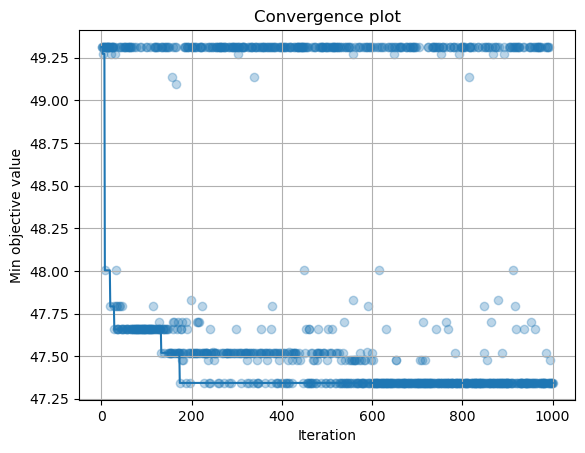

In [42]:
import matplotlib.pyplot as plt
history.plot_convergence()
plt.show()

In [43]:
print(history.get_importance())

+-----------+------------+
| Parameter | Importance |
+-----------+------------+
| m_C       | 0.868826   |
| t_RT1     | 0.099591   |
| T_drawH   | 0.000235   |
| T_methyl  | 0.000214   |
| t_RT2     | 0.000121   |
| m_B       | 0.000040   |
+-----------+------------+


In [44]:
history.visualize_html(open_html=True, show_importance=True,
                       verify_surrogate=True, optimizer=opt)

[2023-03-17 11:09:11,499][flow2][INFO][html_visualizer.py:462] Please open the html file to view visualization result: file:///home/z/zsl/flow/flow2/logs/history/flow2/flow2_2023-03-17-11-09-11-497005.html
[2023-03-17 11:09:12,422][flow2][INFO][html_visualizer.py:310] Verify surrogate model...
[2023-03-17 11:09:12,437][flow2][ERROR][html_visualizer.py:346] Exception in generating verify surrogate data!
Traceback (most recent call last):
  File "/home/z/mambaforge-pypy3/envs/zsl/lib/python3.8/site-packages/openbox/visualization/html_visualizer.py", line 319, in generate_verify_surrogate_data
    raise ValueError('Please set surrogate_type in task_info!')
ValueError: Please set surrogate_type in task_info!
[2023-03-17 11:09:12,549][flow2][INFO][html_visualizer.py:96] Please open the html file to view visualization result: file:///home/z/zsl/flow/flow2/logs/history/flow2/flow2_2023-03-17-11-09-11-497005.html
